# Employee Attrition Prediction using Decision Tree and Random Forest Classification

**Dataset:** IBM HR Analytics Employee Attrition & Performance Dataset
**Source:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

This notebook builds and compares Decision Tree and Random Forest classification models
to predict whether an employee is likely to leave the organization (attrition).

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
# 1. Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape of dataset:", df.shape)

Shape of dataset: (1470, 35)


In [3]:
# 2. Display the first five records
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### Identifying feature types

- **Numerical features:** `Age`, `DailyRate`, `DistanceFromHome`, `Education`,
  `EnvironmentSatisfaction`, `HourlyRate`, `JobInvolvement`, `JobLevel`,
  `JobSatisfaction`, `MonthlyIncome`, `MonthlyRate`, `NumCompaniesWorked`,
  `PercentSalaryHike`, `PerformanceRating`, `RelationshipSatisfaction`,
  `StockOptionLevel`, `TotalWorkingYears`, `TrainingTimesLastYear`, `WorkLifeBalance`,
  `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`,
  `YearsWithCurrManager` (plus constant/ID columns `EmployeeCount`, `EmployeeNumber`,
  `StandardHours`, which are removed in preprocessing)
- **Categorical features:** `BusinessTravel`, `Department`, `EducationField`, `Gender`,
  `JobRole`, `MaritalStatus`, `Over18`, `OverTime`
- **Target variable:** `Attrition` (Yes / No)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# Check the class balance of the target variable
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

## Task 2: Data Preprocessing

In [7]:
# Check for missing values
missing = df.isnull().sum()
print("Total missing values:", missing.sum())

Total missing values: 0


The dataset has **no missing values**.

In [8]:
# Remove unnecessary columns:
# - EmployeeCount, StandardHours, Over18 are constant for every row (no predictive value)
# - EmployeeNumber is just a unique ID
for col in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']:
    print(f"{col}: unique values = {df[col].unique() if col != 'EmployeeNumber' else 'ID column'}")

df_clean = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
print("\nRemaining columns:", df_clean.shape[1])

EmployeeCount: unique values = [1]
StandardHours: unique values = [80]
Over18: unique values = <StringArray>
['Y']
Length: 1, dtype: str
EmployeeNumber: unique values = ID column

Remaining columns: 31


In [9]:
# Encode categorical variables
# Binary target and binary feature -> Label Encoding; multi-class categoricals -> One-Hot Encoding
le_target = LabelEncoder()
df_clean['Attrition'] = le_target.fit_transform(df_clean['Attrition'])   # No=0, Yes=1

le_overtime = LabelEncoder()
df_clean['OverTime'] = le_overtime.fit_transform(df_clean['OverTime'])   # No=0, Yes=1

le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])         # Female=0, Male=1

multi_class_cats = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_encoded = pd.get_dummies(df_clean, columns=multi_class_cats, drop_first=True)

bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Final feature set shape:", df_encoded.shape)
df_encoded.head()

Final feature set shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0


In [10]:
# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

print(X.shape, y.shape)

(1470, 44) (1470,)


In [11]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (1176, 44)
Testing set size : (294, 44)


## Task 3: Model Development

### Model 1: Decision Tree Classifier

In [12]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree trained and predictions generated.")

Decision Tree trained and predictions generated.


### Model 2: Random Forest Classifier (100 estimators)

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest trained and predictions generated.")

Random Forest trained and predictions generated.


## Task 4: Model Evaluation and Comparison

In [14]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Accuracy Score : {acc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall         : {rec:.4f}")
    print(f"F1-Score       : {f1:.4f}\n")
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

dt_metrics = evaluate_model(y_test, y_pred_dt, "Decision Tree")
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest")

comparison_df = pd.DataFrame([dt_metrics, rf_metrics]).set_index('Model')
comparison_df

--- Decision Tree ---
Accuracy Score : 0.7585
Precision      : 0.2931
Recall         : 0.3617
F1-Score       : 0.3238

--- Random Forest ---
Accuracy Score : 0.8265
Precision      : 0.3000
Recall         : 0.0638
F1-Score       : 0.1053



,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.758503,0.293103,0.361702,0.323810
Random Forest,0.826531,0.300000,0.063830,0.105263


In [15]:
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

Decision Tree Classification Report:

              precision    recall  f1-score   support

          No       0.87      0.83      0.85       247
         Yes       0.29      0.36      0.32        47

    accuracy                           0.76       294
   macro avg       0.58      0.60      0.59       294
weighted avg       0.78      0.76      0.77       294


Random Forest Classification Report:

              precision    recall  f1-score   support

          No       0.85      0.97      0.90       247
         Yes       0.30      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.57      0.52      0.50       294
weighted avg       0.76      0.83      0.78       294



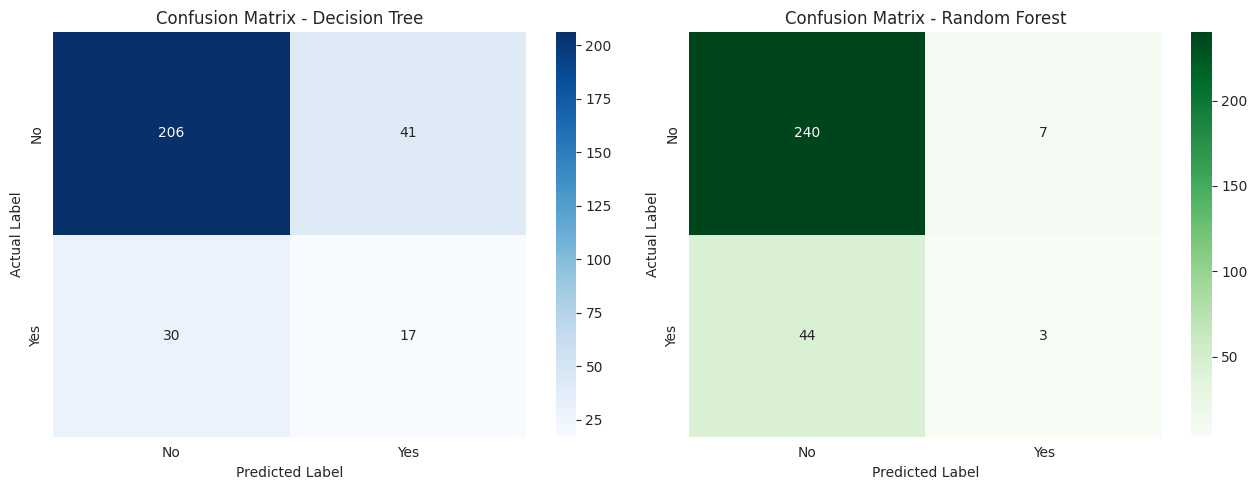

In [16]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()

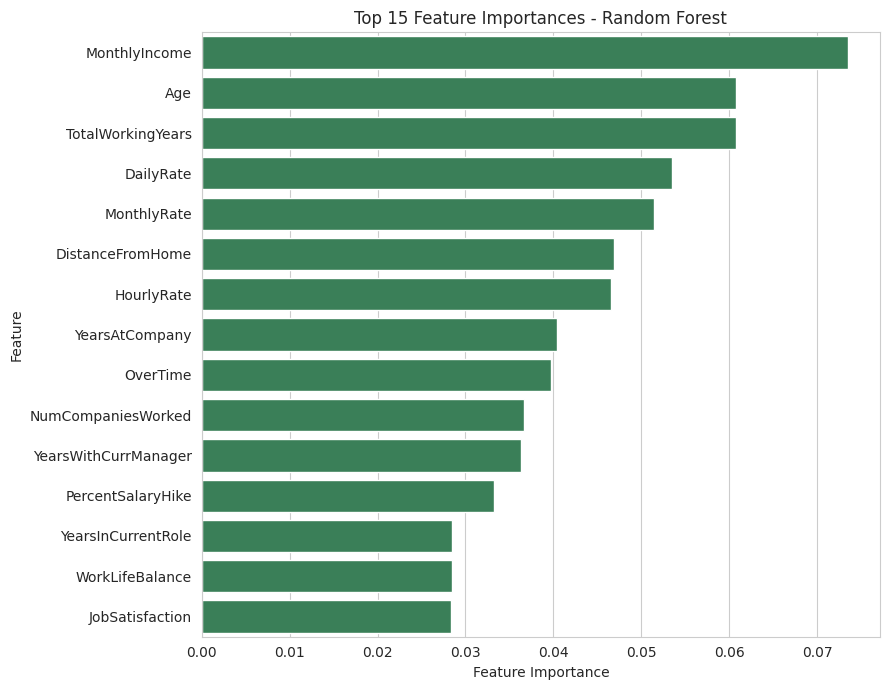

In [17]:
# Feature Importance plot for the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_features.values, y=top_features.index, color='seagreen')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

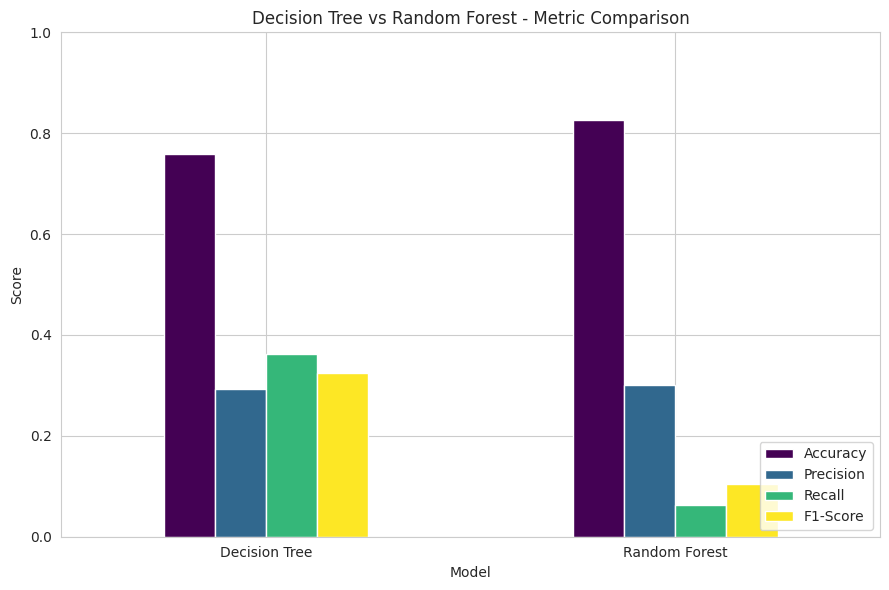

In [18]:
# Side-by-side bar chart comparing the two models across all four metrics
comparison_df.plot(kind='bar', figsize=(9, 6), colormap='viridis')
plt.title('Decision Tree vs Random Forest - Metric Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()

### Observations

1. **Random Forest achieves higher overall accuracy (~82.7%) than the Decision Tree (~75.9%)**, confirming that averaging across 100 trees reduces the overfitting and variance a single Decision Tree is prone to on the majority ("No") class.
2. **However, on the minority "Yes" (attrition) class, the Decision Tree actually achieves better recall and F1-score than Random Forest** (Decision Tree recall ≈ 0.36 vs. Random Forest recall ≈ 0.06 for attrition cases in this run). This is a direct consequence of the dataset's class imbalance (only ~16% of employees left): Random Forest's averaging tends to favor the majority class, so it predicts "No" far more often and misses most true attrition cases, while the single Decision Tree -- despite being noisier overall -- happens to split more aggressively toward the minority class.
3. **This highlights a critical lesson for real-world HR use**: if the business goal is to *catch as many at-risk employees as possible* (high recall on attrition), accuracy alone is a misleading metric here -- a "smarter"-looking high-accuracy model can actually be worse at the task that matters. Techniques like class weighting (`class_weight='balanced'`), resampling (SMOTE/undersampling), or adjusting the classification threshold would likely be needed to make Random Forest genuinely useful for this business problem.
4. **The feature importance plot shows `MonthlyIncome`, `Age`, `TotalWorkingYears`, `DailyRate`, `OverTime`, and `YearsAtCompany` among the most influential predictors**, aligning with common HR intuition that compensation, tenure, and overtime burden strongly relate to whether an employee stays or leaves.

## Task 5: Conclusion

In this project, both a Decision Tree and a Random Forest (100 estimators) classifier
were trained to predict employee attrition using demographic, professional, and
work-related attributes. **On overall accuracy, Random Forest performed better** (≈82.7%
vs. ≈75.9% for the Decision Tree), consistent with the general expectation that ensembling
many trees reduces the variance and overfitting a single Decision Tree is prone to. However,
a closer look at the classification report reveals a more nuanced picture: **the Decision
Tree actually achieved better recall and F1-score on the minority "attrition = Yes" class**,
meaning it caught more of the employees who actually left, while Random Forest's accuracy
advantage came mostly from being very good at predicting the majority "No" class -- a
direct effect of the dataset's class imbalance (~16% attrition rate). This is a key reminder
that **Random Forest often outperforms Decision Trees** in general because it averages
predictions across many trees trained on bootstrapped samples and random feature subsets,
reducing variance and improving generalization -- but this benefit is not guaranteed on
every metric, especially with imbalanced data. A core **limitation of Decision Trees** is
their tendency to overfit and their instability (small data changes can produce very
different trees), while a core **limitation of Random Forest** is reduced interpretability
and a tendency to be biased toward the majority class in imbalanced problems like this one,
along with higher computational cost. For this business problem, further work such as class
weighting or resampling would likely be needed before deploying either model.